# Modelo de Árbol de Decisión con Poda Extensiva

Este notebook implementa un análisis detallado de árboles de decisión con múltiples
estrategias de poda (pruning), incluyendo:

1. Exploración y preparación de datos
2. Modelo base sin poda (overfitting)
3. Poda por profundidad máxima (`max_depth`)
4. Poda por muestras mínimas (`min_samples_split`, `min_samples_leaf`)
5. Poda por costo-complejidad (`ccp_alpha`) — Cost Complexity Pruning
6. Comparación exhaustiva de todos los modelos
7. Validación cruzada
8. Selección del mejor modelo

## 1. Importaciones y configuración

In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga y exploración de datos

In [2]:
df = pd.read_excel("VISTA_TOTAL.xlsx")
print(f"Dimensiones del dataset: {df.shape}")
print(f"Columnas: {list(df.columns)}")
df.head(10)

Dimensiones del dataset: (18000, 20)
Columnas: ['ID_PEDIDO', 'FECHA', 'ID_CLIENTE', 'Cliente', 'ID_VENDEDOR', 'VENDEDOR', 'Genero_Vendedor', 'Sucursal_Vendedor', 'Provincia_Vendedor', 'latitud', 'longitud', 'Region_Vendedor', 'ID_PRODUCTO', 'Nombre_Producto', 'PRECIO_COMPRA', 'PRECIO_VENTA', 'CANTIDAD', 'INGRESO_TOTAL', 'foto_Productos_url', 'foto_Vendedor_url']


,ID_PEDIDO,FECHA,ID_CLIENTE,Cliente,ID_VENDEDOR,VENDEDOR,Genero_Vendedor,Sucursal_Vendedor,Provincia_Vendedor,latitud,longitud,Region_Vendedor,ID_PRODUCTO,Nombre_Producto,PRECIO_COMPRA,PRECIO_VENTA,CANTIDAD,INGRESO_TOTAL,foto_Productos_url,foto_Vendedor_url
0,1,2022-10-10,9,Luis Diaz,1,Juan Perez,Masculino,Sucursal A,La Altagracia,18.6167,-68.7167,NORTE,11,Verduras frescas,15,35,78,7201.74,https://img.pikbest.com/origin/09/05/38/99KpIk...,https://dl.dropbox.com/s/4bz1xriny7ro04g/A40.png
1,2,2021-04-29,24,Claudia Comila,10,Julio Linarez,Masculino,Sucursal B,La Vega,19.2167,-70.5167,SUR,1,Leche,50,70,34,1878.16,https://png.pngtree.com/png-vector/20240206/ou...,https://uploaddeimagens.com.br/images/002/602/...
2,3,2020-03-22,18,Marta Ramos,2,Maria Vizcaino,Femenino,Sucursal B,El Seibo,18.7667,-69.0333,NORTE,3,Frutas frescas,20,40,2,195.36,https://www.elmonaguillo.com/images/productos/...,https://dl.dropbox.com/s/yxe96df3xrzoc4y/A44.png
3,4,2021-08-14,13,Pablo Perez,1,Juan Perez,Masculino,Sucursal A,La Altagracia,18.6167,-68.7167,NORTE,2,Legumbres,30,50,32,1751.36,https://hslegumbres.com.ar/wp-content/uploads/...,https://dl.dropbox.com/s/4bz1xriny7ro04g/A40.png
4,5,2020-09-12,22,Sara Santana,5,Sofia Bergara,Femenino,Sucursal A,San Pedro de Macorís,18.4616,-69.2973,NORTE,7,Huevos,35,55,22,1820.50,https://acdn.mitiendanube.com/stores/001/926/7...,https://dl.dropboxusercontent.com/s/id0gj57k6z...
5,6,2022-09-18,10,Carmen Santana,10,Julio Linarez,Masculino,Sucursal B,La Vega,19.2167,-70.5167,SUR,5,Aceite,45,65,9,453.06,https://cdn-icons-png.freepik.com/512/5029/502...,https://uploaddeimagens.com.br/images/002/602/...
6,7,2020-02-19,2,María Vizcaino,9,Carlos Santos,Masculino,Sucursal A,Espaillat,19.5753,-70.6467,SUR,15,Miel,75,95,24,1723.92,https://prodexspa.com/wp-content/uploads/2023/...,https://uploaddeimagens.com.br/images/002/602/...
7,8,2020-03-04,11,Miguel Ramos,7,Juan Comila,Masculino,Sucursal C,Puerto Plata,19.7907,-70.6907,SUR,1,Leche,50,70,52,3425.76,https://png.pngtree.com/png-vector/20240206/ou...,https://dl.dropbox.com/s/jveyj0btov87izo/A38.png
8,9,2020-09-22,27,David Santana,11,Pedro Gómez,Masculino,Sucursal C,Azua,18.4667,-70.7333,ESTE,12,Carne de pollo,55,75,44,2503.60,https://carnessanpietro.com/wp-content/uploads...,https://dl.dropboxusercontent.com/s/xnimxsc4d2...
9,10,2024-02-07,4,Laura Diaz,9,Carlos Santos,Masculino,Sucursal A,Espaillat,19.5753,-70.6467,SUR,9,Aceite de oliva,60,80,72,3754.08,https://studikard.com/wp-content/uploads/2021/...,https://uploaddeimagens.com.br/images/002/602/...


In [3]:
print("=" * 60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)
df.info()
print("\n")
print("=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
df.describe()

INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   ID_PEDIDO           18000 non-null  int64         
 1   FECHA               18000 non-null  datetime64[ns]
 2   ID_CLIENTE          18000 non-null  int64         
 3   Cliente             18000 non-null  object        
 4   ID_VENDEDOR         18000 non-null  int64         
 5   VENDEDOR            18000 non-null  object        
 6   Genero_Vendedor     18000 non-null  object        
 7   Sucursal_Vendedor   18000 non-null  object        
 8   Provincia_Vendedor  18000 non-null  object        
 9   latitud             18000 non-null  float64       
 10  longitud            18000 non-null  float64       
 11  Region_Vendedor     18000 non-null  object        
 12  ID_PRODUCTO         18000 non-null  int64         
 13  Nombre_Product

,ID_PEDIDO,FECHA,ID_CLIENTE,ID_VENDEDOR,latitud,longitud,ID_PRODUCTO,PRECIO_COMPRA,PRECIO_VENTA,CANTIDAD,INGRESO_TOTAL
count,18000.000000,18000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,9000.500000,2023-03-22 05:10:19.199999744,15.412944,8.002611,18.834562,-70.135594,7.989611,40.332500,60.332500,50.574111,3754.034812
min,1.000000,2020-01-01 00:00:00,1.000000,1.000000,18.208500,-71.229400,1.000000,10.000000,30.000000,1.000000,35.000000
25%,4500.750000,2022-01-03 18:00:00,8.000000,4.000000,18.427300,-70.697300,4.000000,25.000000,45.000000,26.000000,1813.762500
50%,9000.500000,2024-01-06 12:00:00,15.000000,8.000000,18.766700,-70.516700,8.000000,40.000000,60.000000,51.000000,3587.630000
75%,13500.250000,2024-07-02 00:00:00,23.000000,12.000000,19.216700,-69.250000,12.000000,55.000000,75.000000,76.000000,5426.295000
max,18000.000000,2024-07-12 00:00:00,30.000000,15.000000,19.790700,-68.716700,15.000000,75.000000,95.000000,100.000000,9979.000000
std,5196.296758,NaN,8.691979,4.303883,0.484528,0.810845,4.318177,18.379597,18.379597,28.916363,2318.616682


In [4]:
print("=" * 60)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: Region_Vendedor")
print("=" * 60)
print(df["Region_Vendedor"].value_counts())
print("\nPorcentajes:")
print(df["Region_Vendedor"].value_counts(normalize=True).round(4) * 100)

DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: Region_Vendedor
Region_Vendedor
SUR      6122
NORTE    5945
ESTE     5933
Name: count, dtype: int64

Porcentajes:
Region_Vendedor
SUR      34.01
NORTE    33.03
ESTE     32.96
Name: proportion, dtype: float64


In [5]:
print("=" * 60)
print("VALORES NULOS POR COLUMNA")
print("=" * 60)
print(df.isnull().sum())
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")

VALORES NULOS POR COLUMNA
ID_PEDIDO             0
FECHA                 0
ID_CLIENTE            0
Cliente               0
ID_VENDEDOR           0
VENDEDOR              0
Genero_Vendedor       0
Sucursal_Vendedor     0
Provincia_Vendedor    0
latitud               0
longitud              0
Region_Vendedor       0
ID_PRODUCTO           0
Nombre_Producto       0
PRECIO_COMPRA         0
PRECIO_VENTA          0
CANTIDAD              0
INGRESO_TOTAL         0
foto_Productos_url    0
foto_Vendedor_url     0
dtype: int64

Total de valores nulos: 0


## 3. Preparación de datos

In [6]:
# Definir features (X) y target (y)
feature_cols = ["PRECIO_COMPRA", "PRECIO_VENTA", "CANTIDAD"]
x = df[feature_cols]
y = df["Region_Vendedor"]

print(f"Features seleccionadas: {feature_cols}")
print(f"Variable objetivo: Region_Vendedor")
print(f"Clases únicas: {list(y.unique())}")
print(f"Número de clases: {y.nunique()}")

Features seleccionadas: ['PRECIO_COMPRA', 'PRECIO_VENTA', 'CANTIDAD']
Variable objetivo: Region_Vendedor
Clases únicas: ['NORTE', 'SUR', 'ESTE']
Número de clases: 3


In [7]:
# División entrenamiento/prueba (80/20)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Datos de entrenamiento: {x_train.shape[0]} registros ({x_train.shape[0]/len(x)*100:.1f}%)")
print(f"Datos de prueba:        {x_test.shape[0]} registros ({x_test.shape[0]/len(x)*100:.1f}%)")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts())
print(f"\nDistribución en prueba:")
print(y_test.value_counts())

Datos de entrenamiento: 14400 registros (80.0%)
Datos de prueba:        3600 registros (20.0%)

Distribución en entrenamiento:
Region_Vendedor
SUR      4898
NORTE    4756
ESTE     4746
Name: count, dtype: int64

Distribución en prueba:
Region_Vendedor
SUR      1224
NORTE    1189
ESTE     1187
Name: count, dtype: int64


## 4. Modelo base SIN poda (sobreajuste / overfitting)

In [8]:
# Modelo sin restricciones — propenso al sobreajuste
modelo_base = DecisionTreeClassifier(criterion="gini", random_state=42)
modelo_base.fit(x_train, y_train)

# Predicciones
y_pred_train_base = modelo_base.predict(x_train)
y_pred_test_base = modelo_base.predict(x_test)

acc_train_base = accuracy_score(y_train, y_pred_train_base)
acc_test_base = accuracy_score(y_test, y_pred_test_base)

print("=" * 60)
print("MODELO BASE (SIN PODA)")
print("=" * 60)
print(f"Profundidad del árbol: {modelo_base.get_depth()}")
print(f"Número de hojas:       {modelo_base.get_n_leaves()}")
print(f"Accuracy entrenamiento: {acc_train_base:.4f}")
print(f"Accuracy prueba:        {acc_test_base:.4f}")
print(f"Diferencia (overfitting): {acc_train_base - acc_test_base:.4f}")
print(f"\nReporte de clasificación (datos de prueba):")
print(classification_report(y_test, y_pred_test_base))

MODELO BASE (SIN PODA)
Profundidad del árbol: 31
Número de hojas:       1300
Accuracy entrenamiento: 0.4799
Accuracy prueba:        0.3317
Diferencia (overfitting): 0.1483

Reporte de clasificación (datos de prueba):
              precision    recall  f1-score   support

        ESTE       0.33      0.41      0.37      1187
       NORTE       0.34      0.32      0.33      1189
         SUR       0.32      0.26      0.29      1224

    accuracy                           0.33      3600
   macro avg       0.33      0.33      0.33      3600
weighted avg       0.33      0.33      0.33      3600



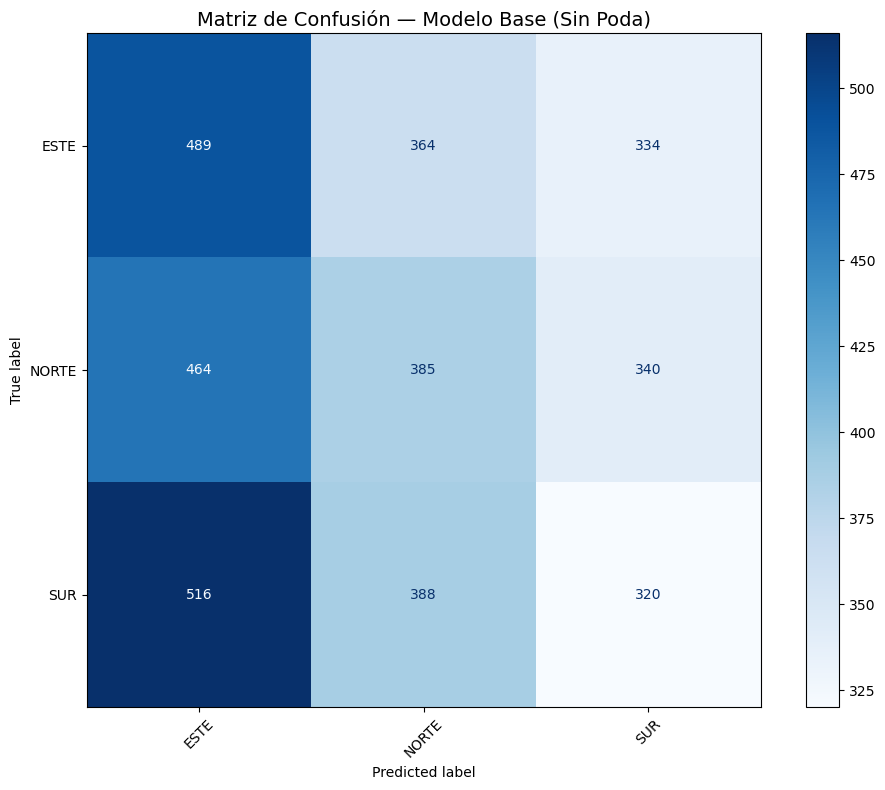

In [9]:
# Matriz de confusión del modelo base
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test_base, ax=ax, cmap='Blues',
    xticks_rotation=45
)
ax.set_title("Matriz de Confusión — Modelo Base (Sin Poda)", fontsize=14)
plt.tight_layout()
plt.show()

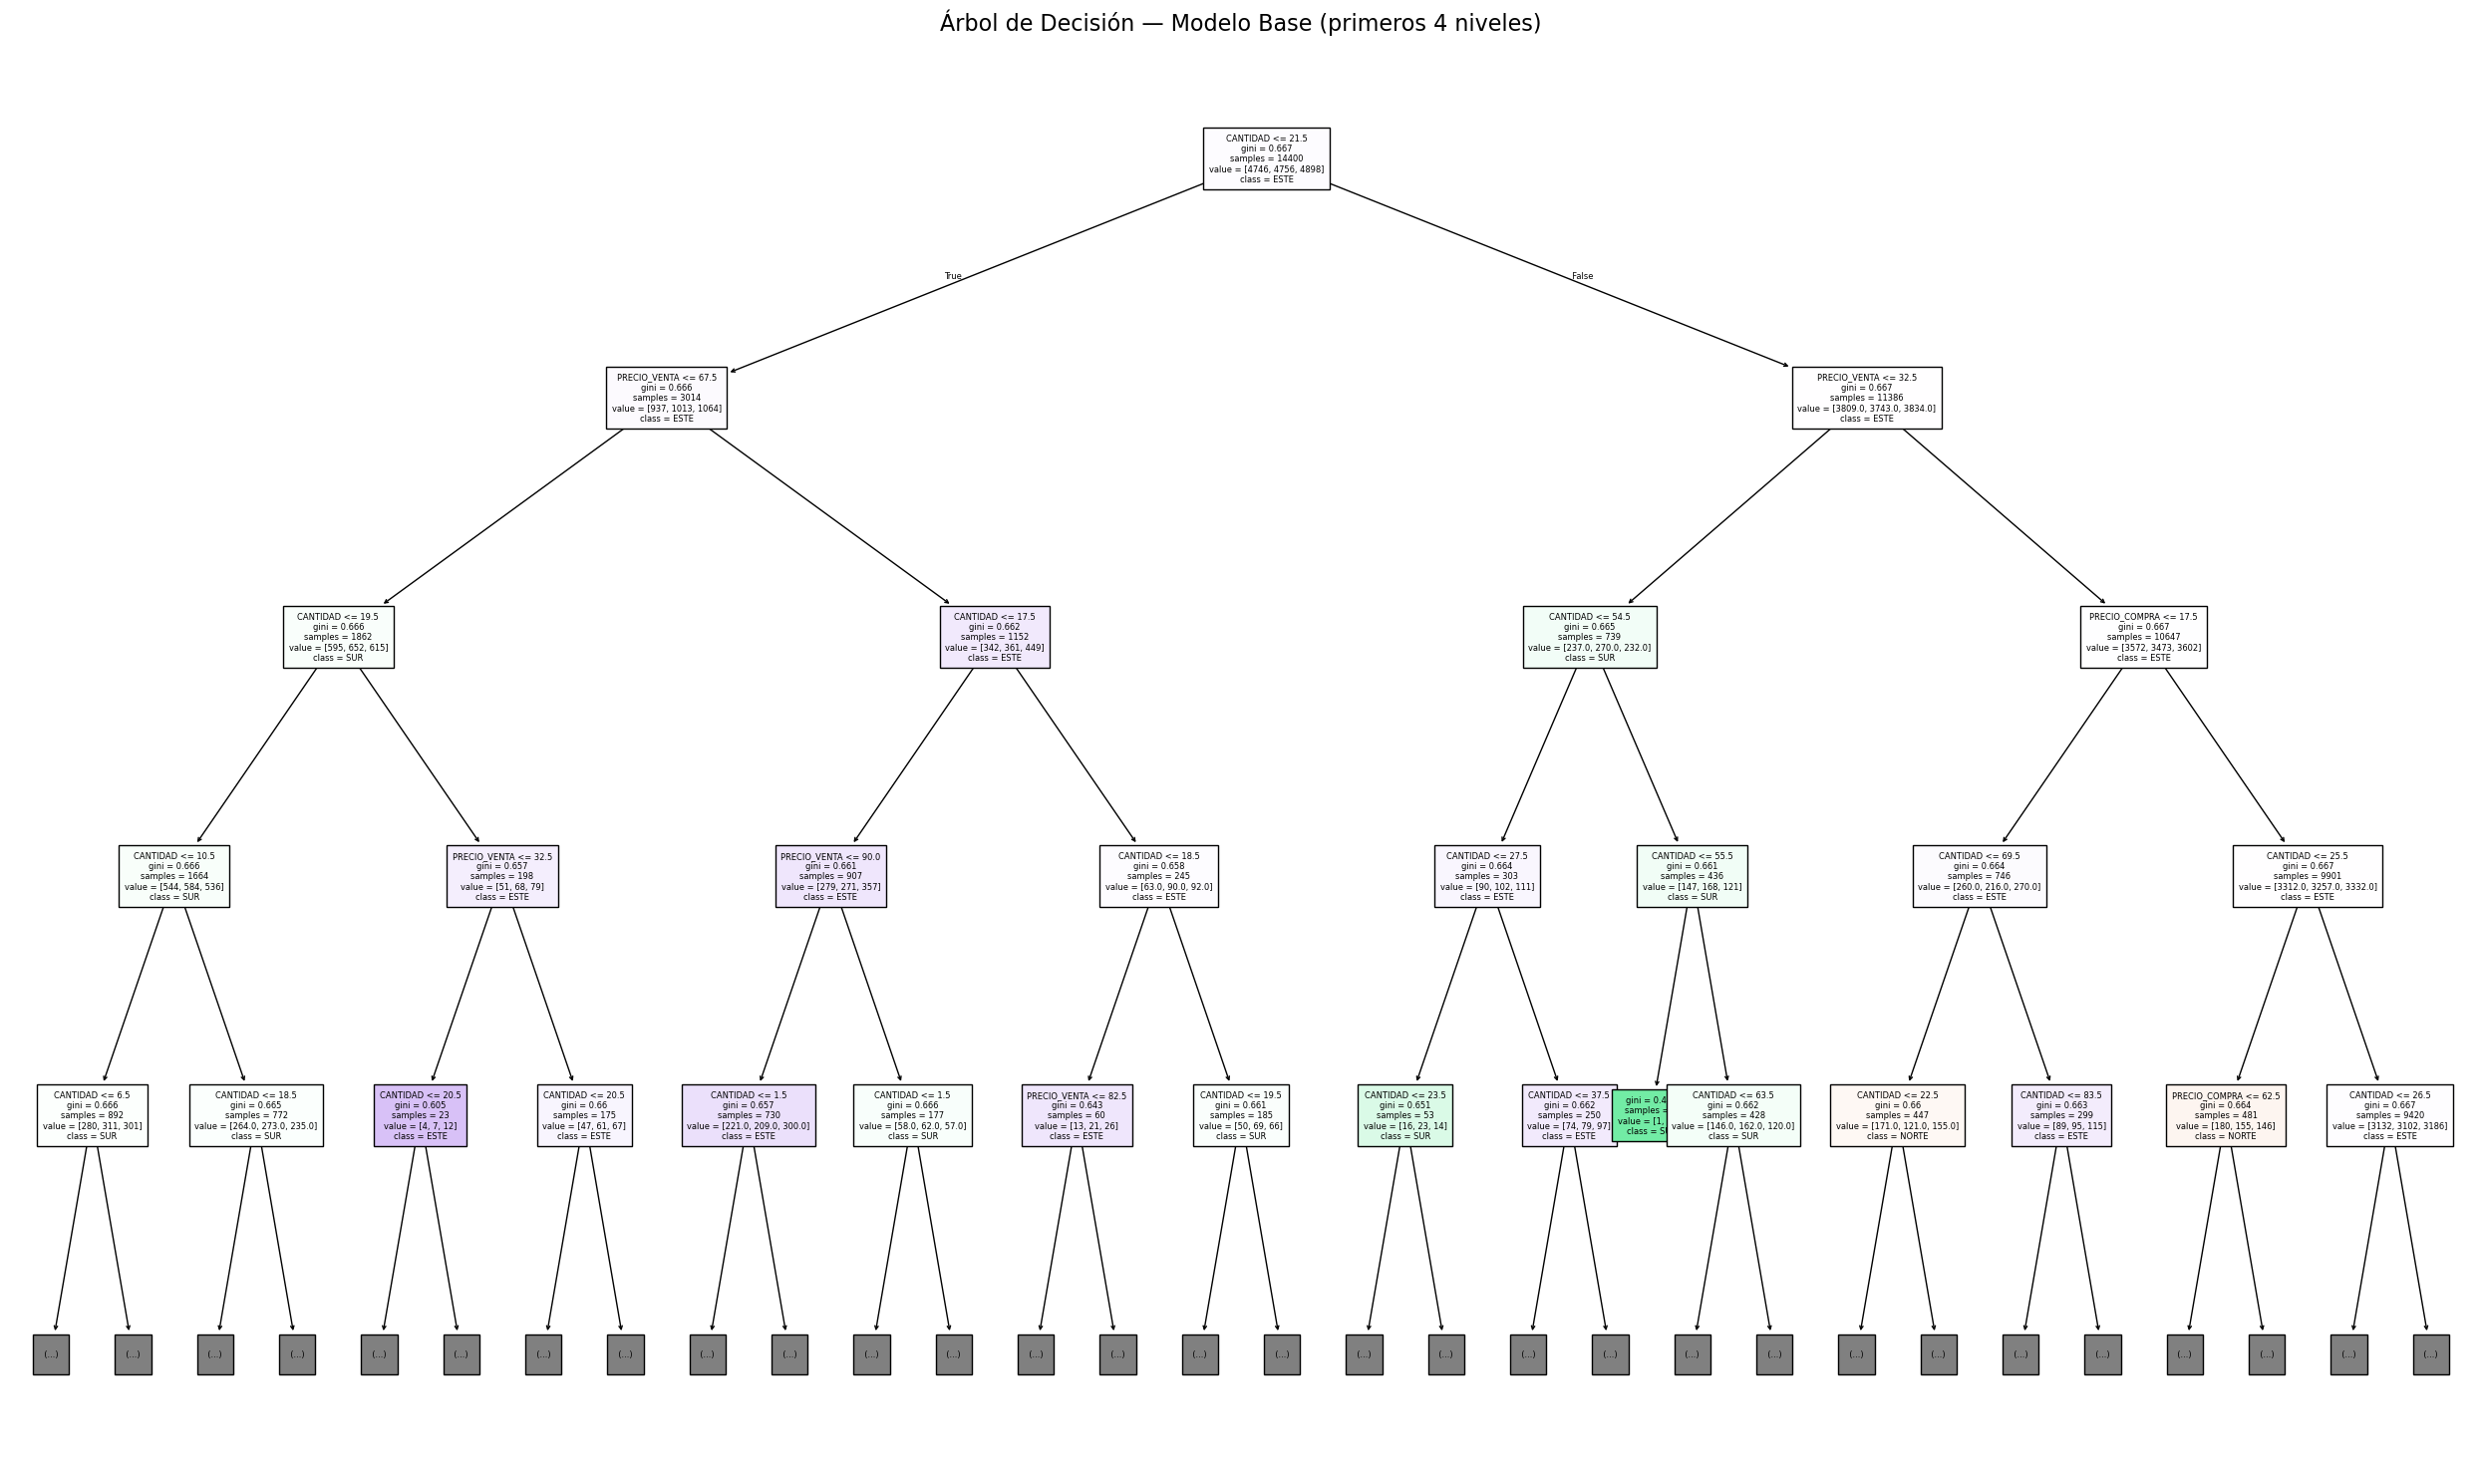

In [10]:
# Visualización del árbol base (puede ser muy grande)
plt.figure(figsize=(25, 15))
plot_tree(
    modelo_base, filled=True,
    feature_names=feature_cols,
    class_names=list(y.unique()),
    fontsize=6,
    max_depth=4  # Limitar visualización a 4 niveles para legibilidad
)
plt.title("Árbol de Decisión — Modelo Base (primeros 4 niveles)", fontsize=16)
plt.tight_layout()
plt.show()

## 5. Poda por profundidad máxima (`max_depth`)

Se evalúan diferentes profundidades para encontrar el punto óptimo
donde el modelo generaliza mejor sin sobreajustar.

In [11]:
# Búsqueda del mejor max_depth
depths = range(1, 21)
results_depth = []

for d in depths:
    modelo = DecisionTreeClassifier(criterion="gini", max_depth=d, random_state=42)
    modelo.fit(x_train, y_train)
    
    acc_train = accuracy_score(y_train, modelo.predict(x_train))
    acc_test = accuracy_score(y_test, modelo.predict(x_test))
    cv_scores = cross_val_score(modelo, x, y, cv=5, scoring='accuracy')
    
    results_depth.append({
        'max_depth': d,
        'acc_train': acc_train,
        'acc_test': acc_test,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'n_leaves': modelo.get_n_leaves(),
        'overfitting': acc_train - acc_test
    })

df_depth = pd.DataFrame(results_depth)
print("=" * 80)
print("RESULTADOS: PODA POR PROFUNDIDAD MÁXIMA")
print("=" * 80)
print(df_depth.to_string(index=False))

RESULTADOS: PODA POR PROFUNDIDAD MÁXIMA
 max_depth  acc_train  acc_test  cv_mean   cv_std  n_leaves  overfitting
         1   0.340139  0.340000 0.339556 0.001250         2     0.000139
         2   0.345347  0.337222 0.335667 0.004930         4     0.008125
         3   0.346736  0.336944 0.335333 0.004133         8     0.009792
         4   0.351389  0.338889 0.332111 0.004613        16     0.012500
         5   0.356389  0.338611 0.332944 0.005078        31     0.017778
         6   0.361806  0.339167 0.330833 0.002159        57     0.022639
         7   0.367847  0.336944 0.331278 0.004298        98     0.030903
         8   0.377153  0.340833 0.334000 0.003463       157     0.036319
         9   0.385903  0.336667 0.331833 0.006753       232     0.049236
        10   0.397917  0.337500 0.332444 0.005546       321     0.060417
        11   0.405486  0.339722 0.334611 0.004683       413     0.065764
        12   0.412917  0.339722 0.328944 0.006825       499     0.073194
        13 

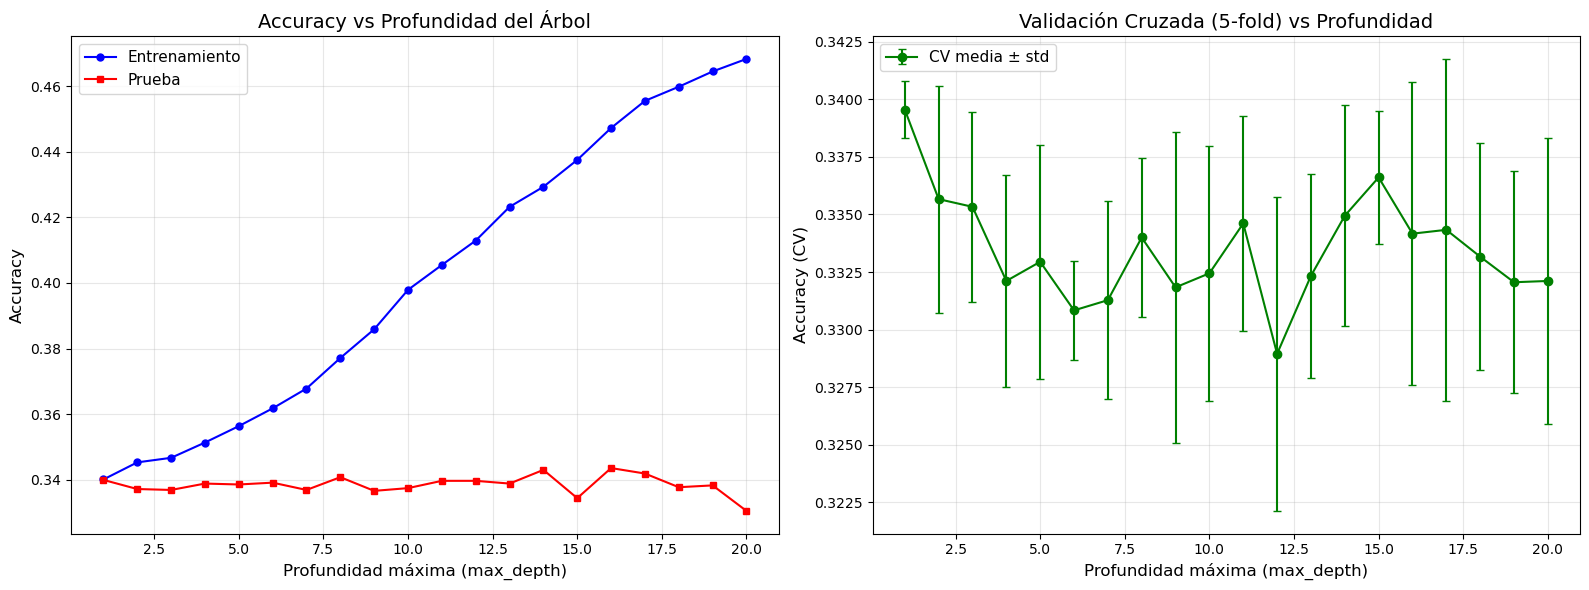


Mejor max_depth según validación cruzada: 1
  CV accuracy: 0.3396 ± 0.0012


In [12]:
# Gráfico de accuracy vs profundidad
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy train vs test
axes[0].plot(df_depth['max_depth'], df_depth['acc_train'], 'b-o', label='Entrenamiento', markersize=5)
axes[0].plot(df_depth['max_depth'], df_depth['acc_test'], 'r-s', label='Prueba', markersize=5)
axes[0].set_xlabel('Profundidad máxima (max_depth)', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy vs Profundidad del Árbol', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Validación cruzada
axes[1].errorbar(
    df_depth['max_depth'], df_depth['cv_mean'], yerr=df_depth['cv_std'],
    fmt='-o', color='green', capsize=3, label='CV media ± std'
)
axes[1].set_xlabel('Profundidad máxima (max_depth)', fontsize=12)
axes[1].set_ylabel('Accuracy (CV)', fontsize=12)
axes[1].set_title('Validación Cruzada (5-fold) vs Profundidad', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mejor profundidad según CV
best_depth = df_depth.loc[df_depth['cv_mean'].idxmax()]
print(f"\nMejor max_depth según validación cruzada: {int(best_depth['max_depth'])}")
print(f"  CV accuracy: {best_depth['cv_mean']:.4f} ± {best_depth['cv_std']:.4f}")

In [13]:
# Entrenar el mejor modelo por profundidad
best_max_depth = int(best_depth['max_depth'])
modelo_depth = DecisionTreeClassifier(
    criterion="gini", max_depth=best_max_depth, random_state=42
)
modelo_depth.fit(x_train, y_train)
y_pred_depth = modelo_depth.predict(x_test)

print(f"\n{'='*60}")
print(f"MODELO PODADO POR PROFUNDIDAD (max_depth={best_max_depth})")
print(f"{'='*60}")
print(f"Profundidad: {modelo_depth.get_depth()}")
print(f"Hojas: {modelo_depth.get_n_leaves()}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_depth):.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_depth))


MODELO PODADO POR PROFUNDIDAD (max_depth=1)
Profundidad: 1
Hojas: 2
Accuracy: 0.3400

Reporte de clasificación:
              precision    recall  f1-score   support

        ESTE       0.00      0.00      0.00      1187
       NORTE       0.00      0.00      0.00      1189
         SUR       0.34      1.00      0.51      1224

    accuracy                           0.34      3600
   macro avg       0.11      0.33      0.17      3600
weighted avg       0.12      0.34      0.17      3600



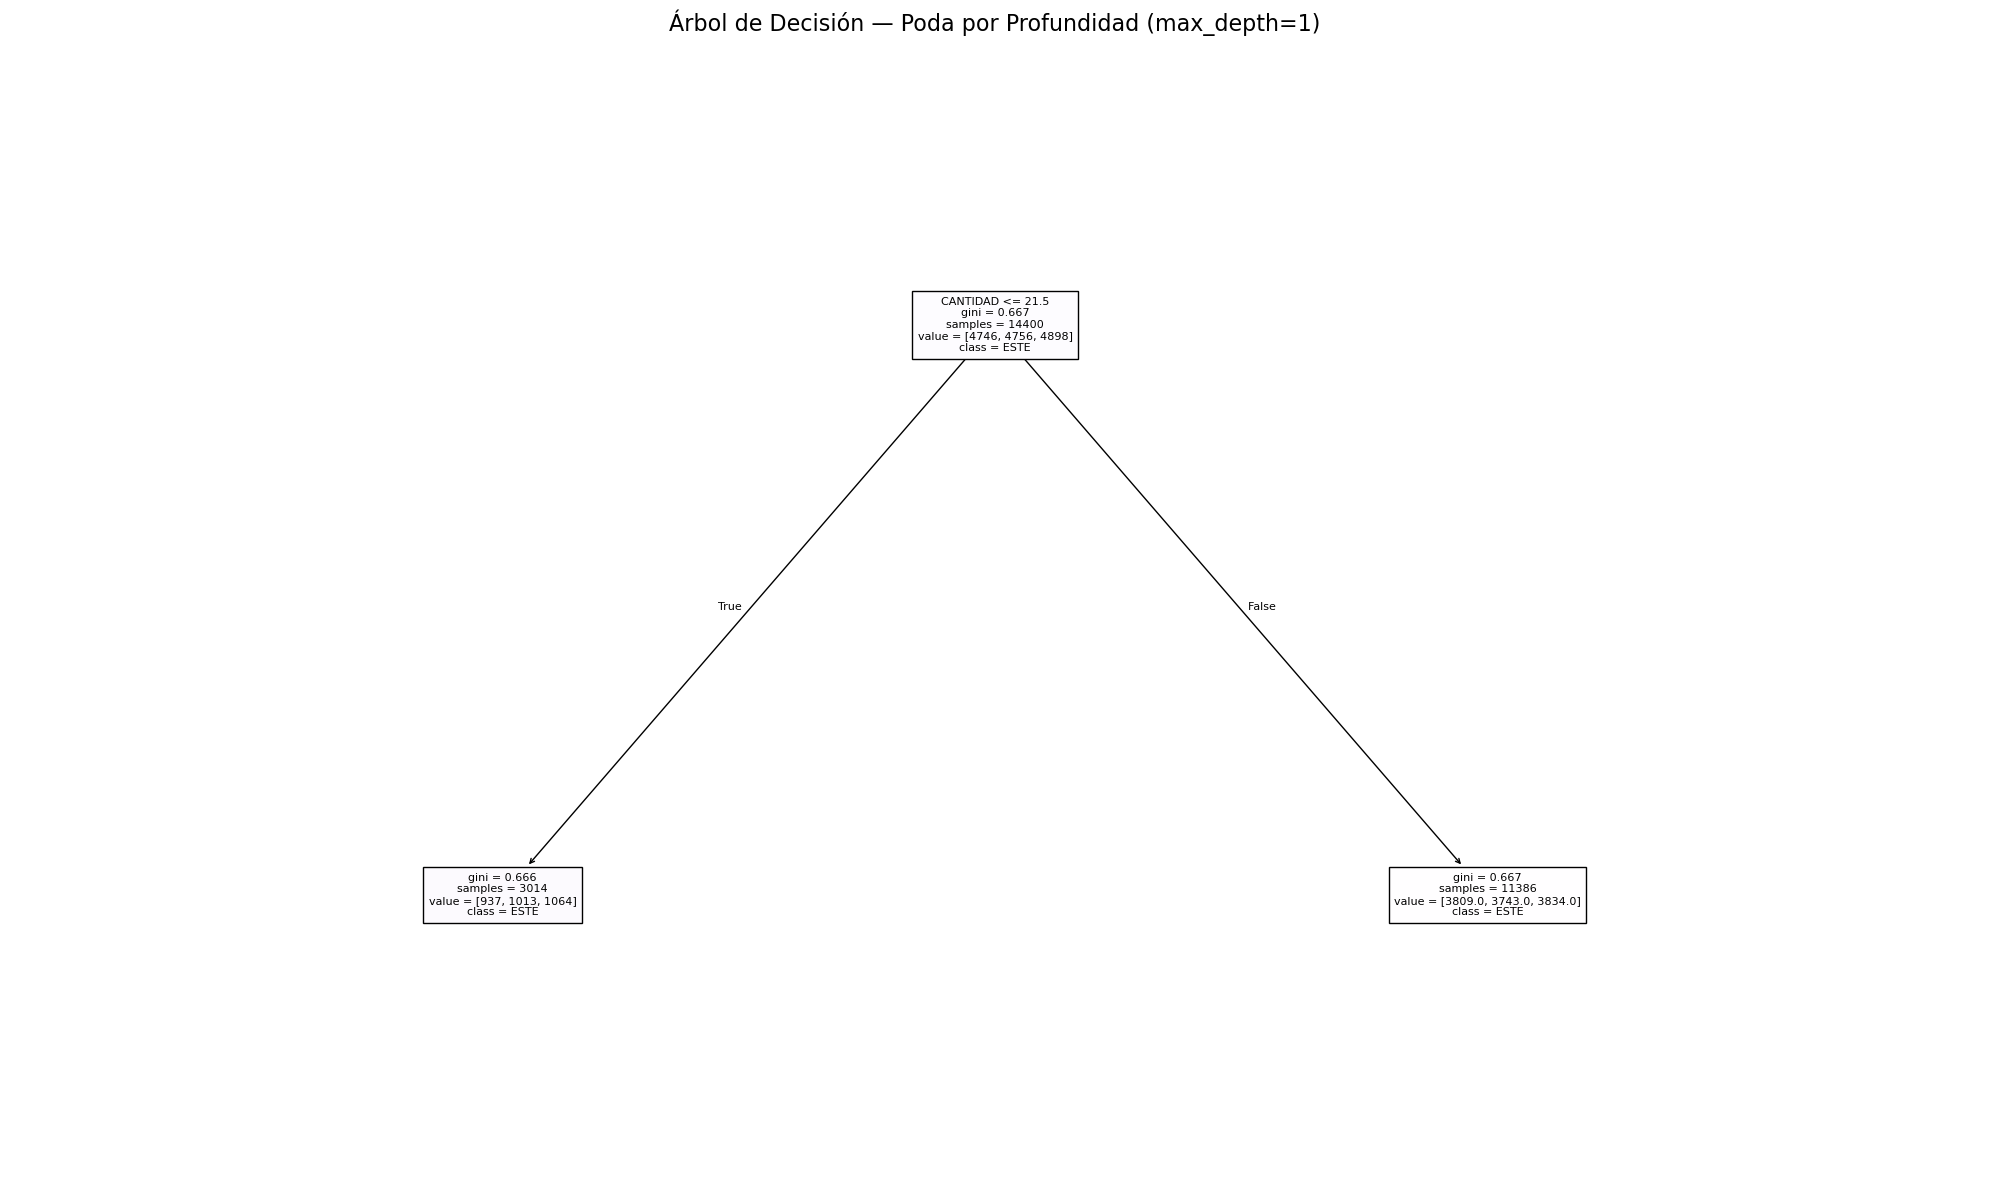

In [14]:
# Visualización del árbol podado por profundidad
plt.figure(figsize=(20, 12))
plot_tree(
    modelo_depth, filled=True,
    feature_names=feature_cols,
    class_names=list(y.unique()),
    fontsize=8
)
plt.title(f"Árbol de Decisión — Poda por Profundidad (max_depth={best_max_depth})", fontsize=16)
plt.tight_layout()
plt.show()

## 6. Poda por muestras mínimas (`min_samples_split` y `min_samples_leaf`)

Controlar el número mínimo de muestras requeridas para dividir un nodo
y el número mínimo de muestras en cada hoja.

In [15]:
# Búsqueda de mejores hiperparámetros de muestras mínimas
results_samples = []

for min_split in [2, 5, 10, 20, 30, 50]:
    for min_leaf in [1, 2, 5, 10, 15, 20]:
        modelo = DecisionTreeClassifier(
            criterion="gini",
            min_samples_split=min_split,
            min_samples_leaf=min_leaf,
            random_state=42
        )
        modelo.fit(x_train, y_train)
        
        acc_train = accuracy_score(y_train, modelo.predict(x_train))
        acc_test = accuracy_score(y_test, modelo.predict(x_test))
        cv_scores = cross_val_score(modelo, x, y, cv=5, scoring='accuracy')
        
        results_samples.append({
            'min_samples_split': min_split,
            'min_samples_leaf': min_leaf,
            'acc_train': acc_train,
            'acc_test': acc_test,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'depth': modelo.get_depth(),
            'n_leaves': modelo.get_n_leaves(),
            'overfitting': acc_train - acc_test
        })

df_samples = pd.DataFrame(results_samples)
df_samples_sorted = df_samples.sort_values('cv_mean', ascending=False).head(10)

print("=" * 100)
print("TOP 10 COMBINACIONES — PODA POR MUESTRAS MÍNIMAS")
print("=" * 100)
print(df_samples_sorted.to_string(index=False))

TOP 10 COMBINACIONES — PODA POR MUESTRAS MÍNIMAS
 min_samples_split  min_samples_leaf  acc_train  acc_test  cv_mean   cv_std  depth  n_leaves  overfitting
                10                10   0.461736  0.337500 0.335167 0.003954     31       882     0.124236
                 2                10   0.461736  0.337500 0.335167 0.003954     31       882     0.124236
                20                10   0.461736  0.337500 0.335167 0.003954     31       882     0.124236
                 5                10   0.461736  0.337500 0.335167 0.003954     31       882     0.124236
                 2                 1   0.479931  0.331667 0.331833 0.004359     31      1300     0.148264
                 5                 1   0.479931  0.331667 0.331833 0.004359     31      1300     0.148264
                 2                 5   0.479167  0.331111 0.331722 0.004019     31      1267     0.148056
                 5                 5   0.479167  0.331111 0.331722 0.004019     31      1267     0.1480

In [16]:
# Mejor modelo por muestras mínimas
best_sample = df_samples.loc[df_samples['cv_mean'].idxmax()]
best_min_split = int(best_sample['min_samples_split'])
best_min_leaf = int(best_sample['min_samples_leaf'])

modelo_samples = DecisionTreeClassifier(
    criterion="gini",
    min_samples_split=best_min_split,
    min_samples_leaf=best_min_leaf,
    random_state=42
)
modelo_samples.fit(x_train, y_train)
y_pred_samples = modelo_samples.predict(x_test)

print(f"\n{'='*60}")
print(f"MODELO PODADO POR MUESTRAS MÍNIMAS")
print(f"  min_samples_split={best_min_split}, min_samples_leaf={best_min_leaf}")
print(f"{'='*60}")
print(f"Profundidad: {modelo_samples.get_depth()}")
print(f"Hojas: {modelo_samples.get_n_leaves()}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_samples):.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_samples))


MODELO PODADO POR MUESTRAS MÍNIMAS
  min_samples_split=2, min_samples_leaf=10
Profundidad: 31
Hojas: 882
Accuracy: 0.3375

Reporte de clasificación:
              precision    recall  f1-score   support

        ESTE       0.34      0.39      0.36      1187
       NORTE       0.33      0.31      0.32      1189
         SUR       0.34      0.32      0.33      1224

    accuracy                           0.34      3600
   macro avg       0.34      0.34      0.34      3600
weighted avg       0.34      0.34      0.34      3600



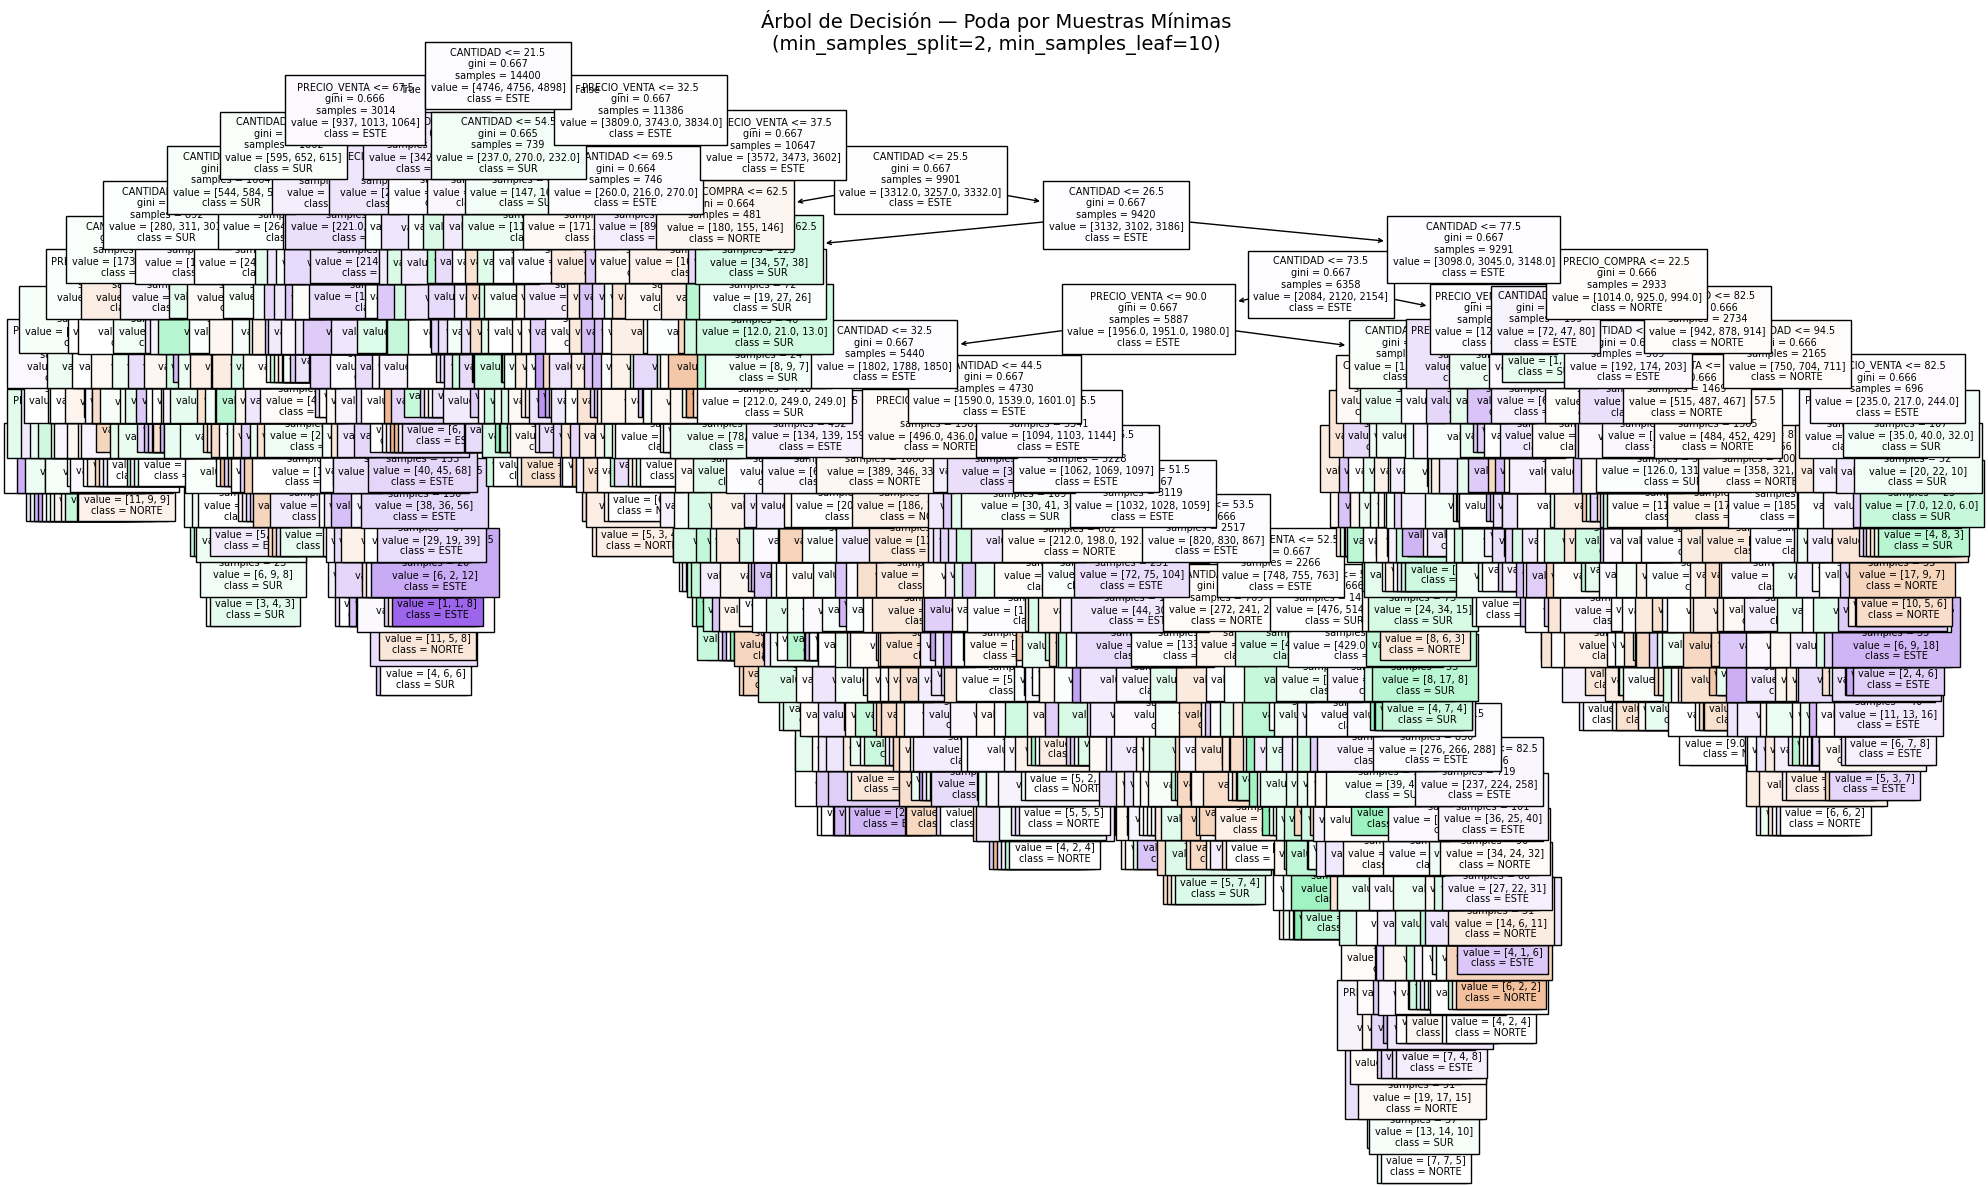

In [17]:
# Visualización del árbol podado por muestras mínimas
plt.figure(figsize=(20, 12))
plot_tree(
    modelo_samples, filled=True,
    feature_names=feature_cols,
    class_names=list(y.unique()),
    fontsize=7
)
plt.title(
    f"Árbol de Decisión — Poda por Muestras Mínimas\n"
    f"(min_samples_split={best_min_split}, min_samples_leaf={best_min_leaf})",
    fontsize=14
)
plt.tight_layout()
plt.show()

## 7. Poda por costo-complejidad (`ccp_alpha`) — Cost Complexity Pruning

Esta es la técnica de poda más sofisticada. El parámetro `ccp_alpha` controla
la penalización por complejidad del árbol. A mayor `ccp_alpha`, mayor poda.

Número de valores de alpha evaluados: 813
Rango de alpha: [0.000000, 0.000206]


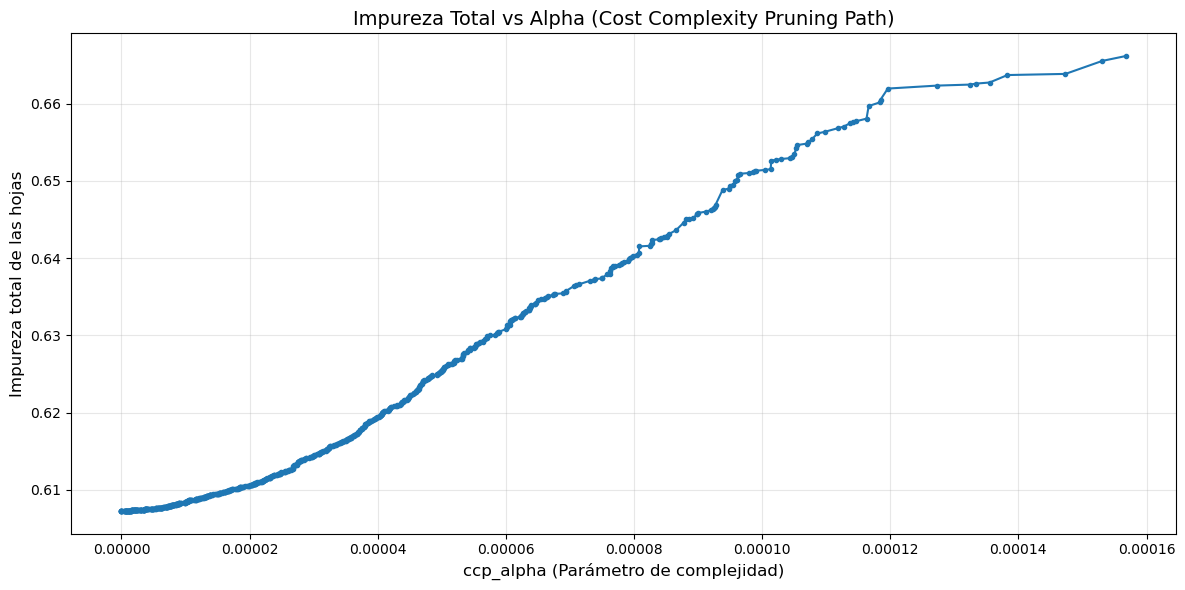

In [18]:
# Obtener la ruta de costo-complejidad
modelo_ccp_full = DecisionTreeClassifier(criterion="gini", random_state=42)
modelo_ccp_full.fit(x_train, y_train)

path = modelo_ccp_full.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f"Número de valores de alpha evaluados: {len(ccp_alphas)}")
print(f"Rango de alpha: [{ccp_alphas.min():.6f}, {ccp_alphas.max():.6f}]")

# Gráfico de impureza vs alpha
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', markersize=3)
ax.set_xlabel('ccp_alpha (Parámetro de complejidad)', fontsize=12)
ax.set_ylabel('Impureza total de las hojas', fontsize=12)
ax.set_title('Impureza Total vs Alpha (Cost Complexity Pruning Path)', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

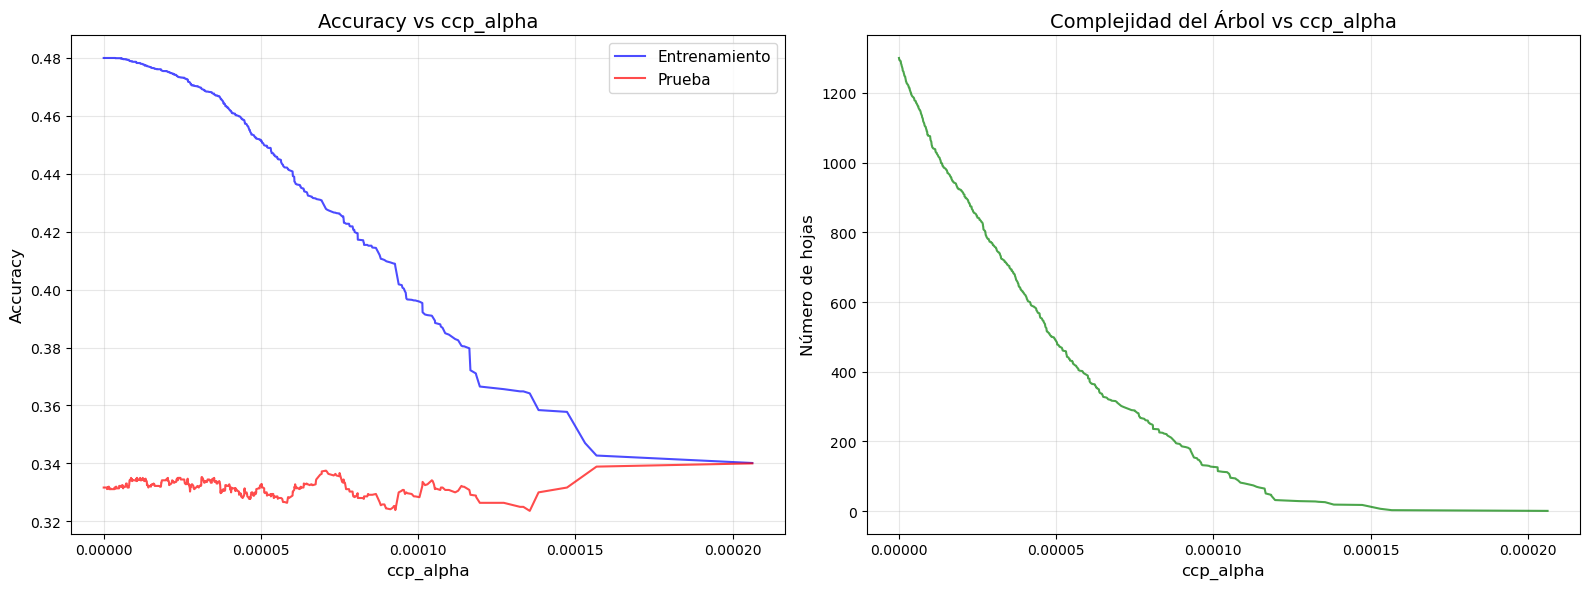

In [19]:
# Entrenar modelos para cada alpha y evaluar
results_ccp = []

for alpha in ccp_alphas:
    modelo = DecisionTreeClassifier(
        criterion="gini", ccp_alpha=alpha, random_state=42
    )
    modelo.fit(x_train, y_train)
    
    acc_train = accuracy_score(y_train, modelo.predict(x_train))
    acc_test = accuracy_score(y_test, modelo.predict(x_test))
    
    results_ccp.append({
        'ccp_alpha': alpha,
        'acc_train': acc_train,
        'acc_test': acc_test,
        'depth': modelo.get_depth(),
        'n_leaves': modelo.get_n_leaves(),
        'overfitting': acc_train - acc_test
    })

df_ccp = pd.DataFrame(results_ccp)

# Gráfico accuracy vs alpha
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(df_ccp['ccp_alpha'], df_ccp['acc_train'], 'b-', label='Entrenamiento', alpha=0.7)
axes[0].plot(df_ccp['ccp_alpha'], df_ccp['acc_test'], 'r-', label='Prueba', alpha=0.7)
axes[0].set_xlabel('ccp_alpha', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Accuracy vs ccp_alpha', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_ccp['ccp_alpha'], df_ccp['n_leaves'], 'g-', alpha=0.7)
axes[1].set_xlabel('ccp_alpha', fontsize=12)
axes[1].set_ylabel('Número de hojas', fontsize=12)
axes[1].set_title('Complejidad del Árbol vs ccp_alpha', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

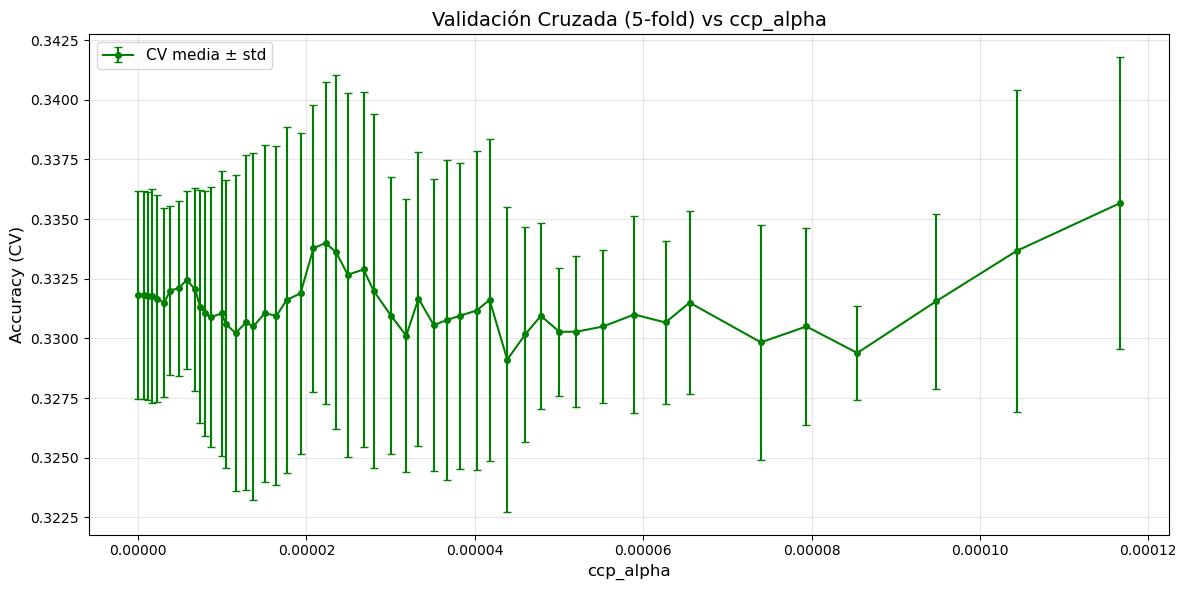


Mejor ccp_alpha según validación cruzada: 0.000117
  CV accuracy: 0.3357 ± 0.0061


In [20]:
# Validación cruzada para seleccionar el mejor alpha
# Usar un subconjunto de alphas para eficiencia
alpha_subset = ccp_alphas[::max(1, len(ccp_alphas) // 50)]  # Máximo 50 alphas
cv_results_ccp = []

for alpha in alpha_subset:
    modelo = DecisionTreeClassifier(
        criterion="gini", ccp_alpha=alpha, random_state=42
    )
    cv_scores = cross_val_score(modelo, x, y, cv=5, scoring='accuracy')
    cv_results_ccp.append({
        'ccp_alpha': alpha,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    })

df_ccp_cv = pd.DataFrame(cv_results_ccp)

# Gráfico de CV vs alpha
fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(
    df_ccp_cv['ccp_alpha'], df_ccp_cv['cv_mean'], yerr=df_ccp_cv['cv_std'],
    fmt='-o', color='green', capsize=3, markersize=4, label='CV media ± std'
)
ax.set_xlabel('ccp_alpha', fontsize=12)
ax.set_ylabel('Accuracy (CV)', fontsize=12)
ax.set_title('Validación Cruzada (5-fold) vs ccp_alpha', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mejor alpha
best_alpha_row = df_ccp_cv.loc[df_ccp_cv['cv_mean'].idxmax()]
best_alpha = best_alpha_row['ccp_alpha']
print(f"\nMejor ccp_alpha según validación cruzada: {best_alpha:.6f}")
print(f"  CV accuracy: {best_alpha_row['cv_mean']:.4f} ± {best_alpha_row['cv_std']:.4f}")

In [21]:
# Entrenar el mejor modelo CCP
modelo_ccp = DecisionTreeClassifier(
    criterion="gini", ccp_alpha=best_alpha, random_state=42
)
modelo_ccp.fit(x_train, y_train)
y_pred_ccp = modelo_ccp.predict(x_test)

print(f"\n{'='*60}")
print(f"MODELO PODADO POR COSTO-COMPLEJIDAD (ccp_alpha={best_alpha:.6f})")
print(f"{'='*60}")
print(f"Profundidad: {modelo_ccp.get_depth()}")
print(f"Hojas: {modelo_ccp.get_n_leaves()}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ccp):.4f}")
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred_ccp))


MODELO PODADO POR COSTO-COMPLEJIDAD (ccp_alpha=0.000117)
Profundidad: 16
Hojas: 51
Accuracy: 0.3292

Reporte de clasificación:
              precision    recall  f1-score   support

        ESTE       0.34      0.31      0.32      1187
       NORTE       0.31      0.25      0.28      1189
         SUR       0.33      0.42      0.37      1224

    accuracy                           0.33      3600
   macro avg       0.33      0.33      0.32      3600
weighted avg       0.33      0.33      0.33      3600



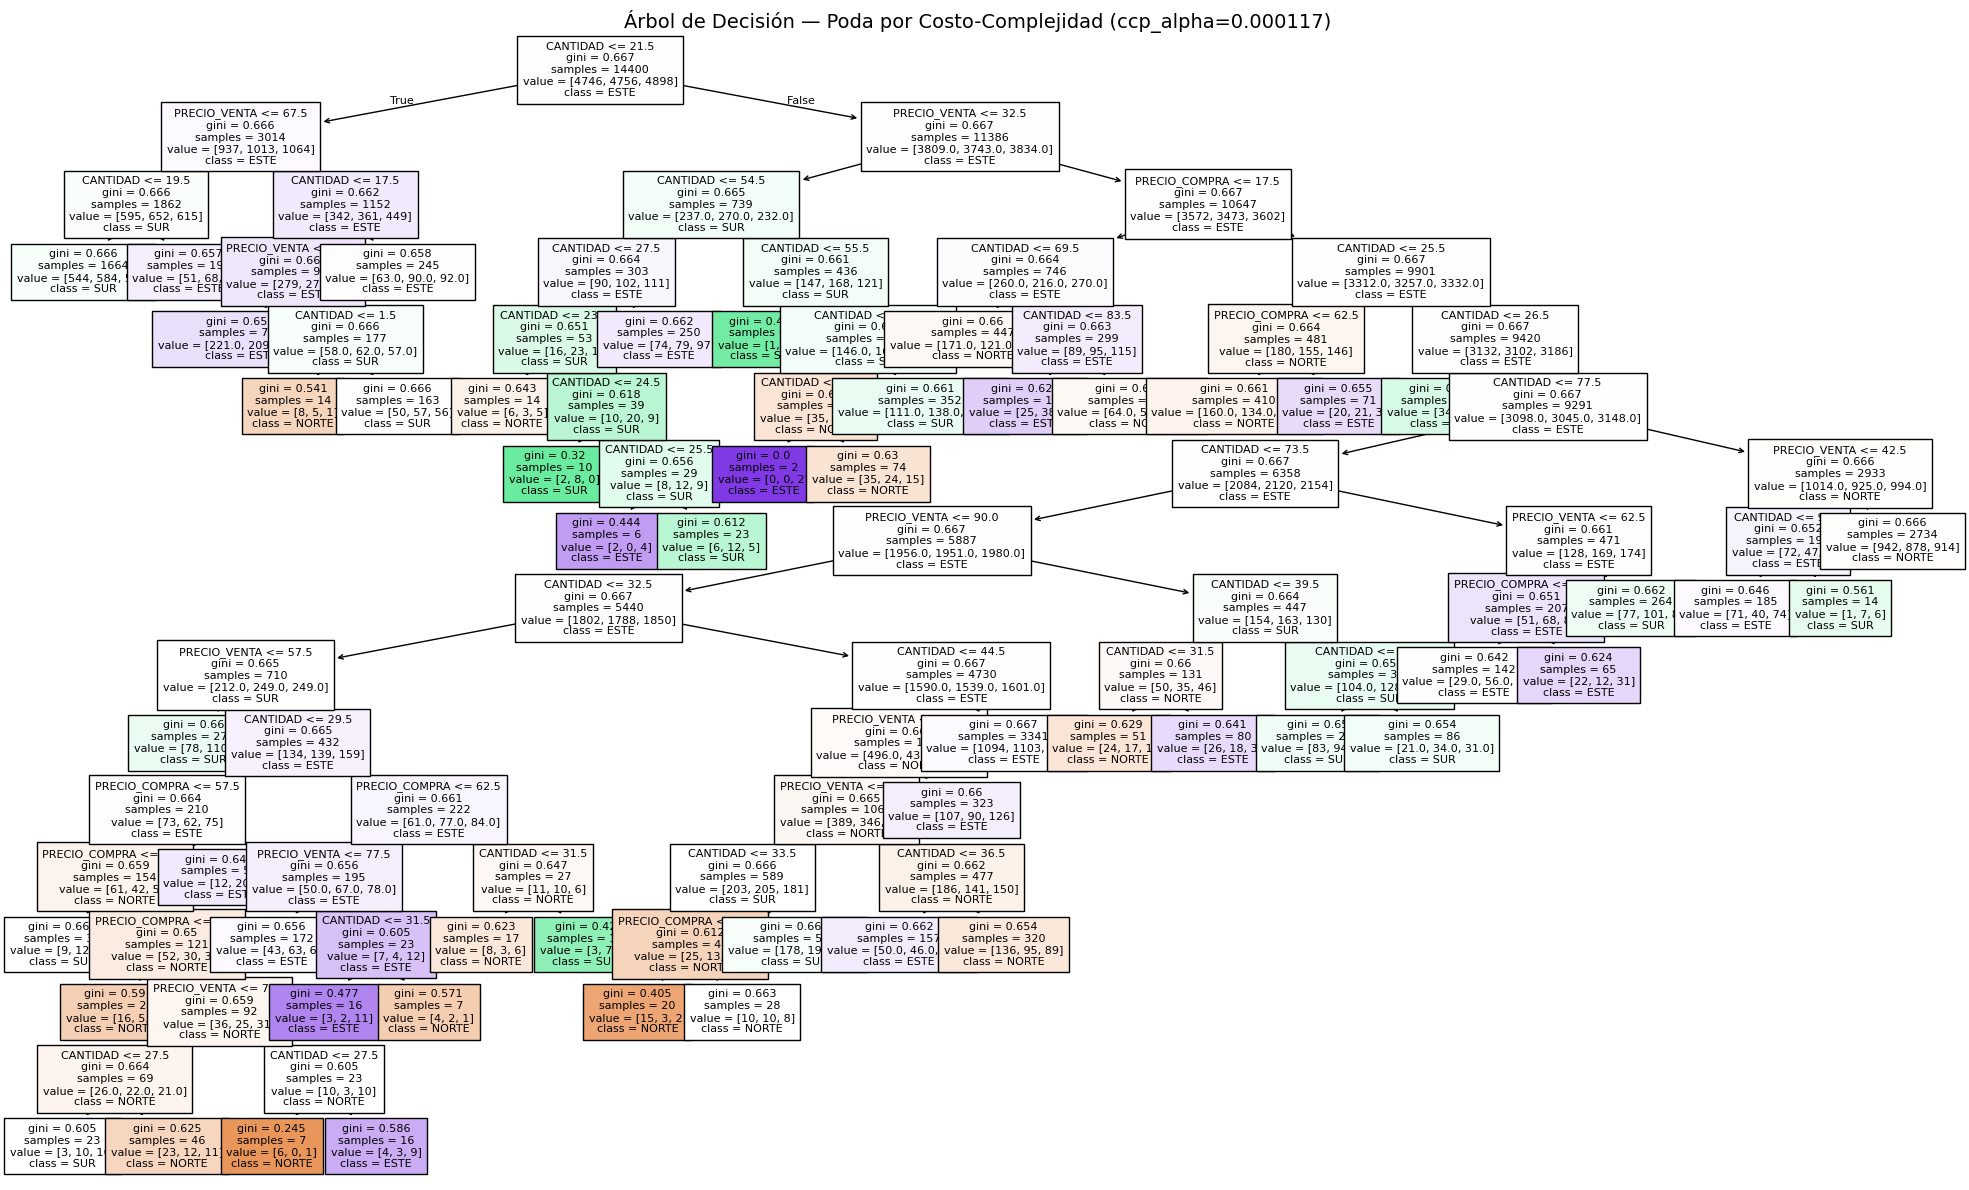

In [22]:
# Visualización del árbol CCP
plt.figure(figsize=(20, 12))
plot_tree(
    modelo_ccp, filled=True,
    feature_names=feature_cols,
    class_names=list(y.unique()),
    fontsize=8
)
plt.title(f"Árbol de Decisión — Poda por Costo-Complejidad (ccp_alpha={best_alpha:.6f})", fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
# Representación textual del árbol CCP
print("=" * 60)
print("REGLAS DEL ÁRBOL — PODA POR COSTO-COMPLEJIDAD")
print("=" * 60)
tree_rules = export_text(
    modelo_ccp,
    feature_names=feature_cols
)
print(tree_rules)

REGLAS DEL ÁRBOL — PODA POR COSTO-COMPLEJIDAD
|--- CANTIDAD <= 21.50
|   |--- PRECIO_VENTA <= 67.50
|   |   |--- CANTIDAD <= 19.50
|   |   |   |--- class: NORTE
|   |   |--- CANTIDAD >  19.50
|   |   |   |--- class: SUR
|   |--- PRECIO_VENTA >  67.50
|   |   |--- CANTIDAD <= 17.50
|   |   |   |--- PRECIO_VENTA <= 90.00
|   |   |   |   |--- class: SUR
|   |   |   |--- PRECIO_VENTA >  90.00
|   |   |   |   |--- CANTIDAD <= 1.50
|   |   |   |   |   |--- class: ESTE
|   |   |   |   |--- CANTIDAD >  1.50
|   |   |   |   |   |--- class: NORTE
|   |   |--- CANTIDAD >  17.50
|   |   |   |--- class: SUR
|--- CANTIDAD >  21.50
|   |--- PRECIO_VENTA <= 32.50
|   |   |--- CANTIDAD <= 54.50
|   |   |   |--- CANTIDAD <= 27.50
|   |   |   |   |--- CANTIDAD <= 23.50
|   |   |   |   |   |--- class: ESTE
|   |   |   |   |--- CANTIDAD >  23.50
|   |   |   |   |   |--- CANTIDAD <= 24.50
|   |   |   |   |   |   |--- class: NORTE
|   |   |   |   |   |--- CANTIDAD >  24.50
|   |   |   |   |   |   |--- CANTID

## 8. Comparación exhaustiva de todos los modelos

In [24]:
# Tabla comparativa
modelos = {
    'Base (sin poda)': modelo_base,
    f'Poda max_depth={best_max_depth}': modelo_depth,
    f'Poda min_split={best_min_split}, min_leaf={best_min_leaf}': modelo_samples,
    f'Poda CCP (alpha={best_alpha:.4f})': modelo_ccp
}

comparison = []
for nombre, modelo in modelos.items():
    y_pred_train = modelo.predict(x_train)
    y_pred_test = modelo.predict(x_test)
    cv_scores = cross_val_score(modelo, x, y, cv=5, scoring='accuracy')
    
    comparison.append({
        'Modelo': nombre,
        'Profundidad': modelo.get_depth(),
        'Hojas': modelo.get_n_leaves(),
        'Acc. Train': f"{accuracy_score(y_train, y_pred_train):.4f}",
        'Acc. Test': f"{accuracy_score(y_test, y_pred_test):.4f}",
        'CV Mean': f"{cv_scores.mean():.4f}",
        'CV Std': f"{cv_scores.std():.4f}",
        'Overfitting': f"{accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred_test):.4f}"
    })

df_comparison = pd.DataFrame(comparison)
print("=" * 120)
print("COMPARACIÓN DE TODOS LOS MODELOS")
print("=" * 120)
print(df_comparison.to_string(index=False))

COMPARACIÓN DE TODOS LOS MODELOS
                       Modelo  Profundidad  Hojas Acc. Train Acc. Test CV Mean CV Std Overfitting
              Base (sin poda)           31   1300     0.4799    0.3317  0.3318 0.0044      0.1483
             Poda max_depth=1            1      2     0.3401    0.3400  0.3396 0.0012      0.0001
Poda min_split=2, min_leaf=10           31    882     0.4617    0.3375  0.3352 0.0040      0.1242
      Poda CCP (alpha=0.0001)           16     51     0.3722    0.3292  0.3357 0.0061      0.0430


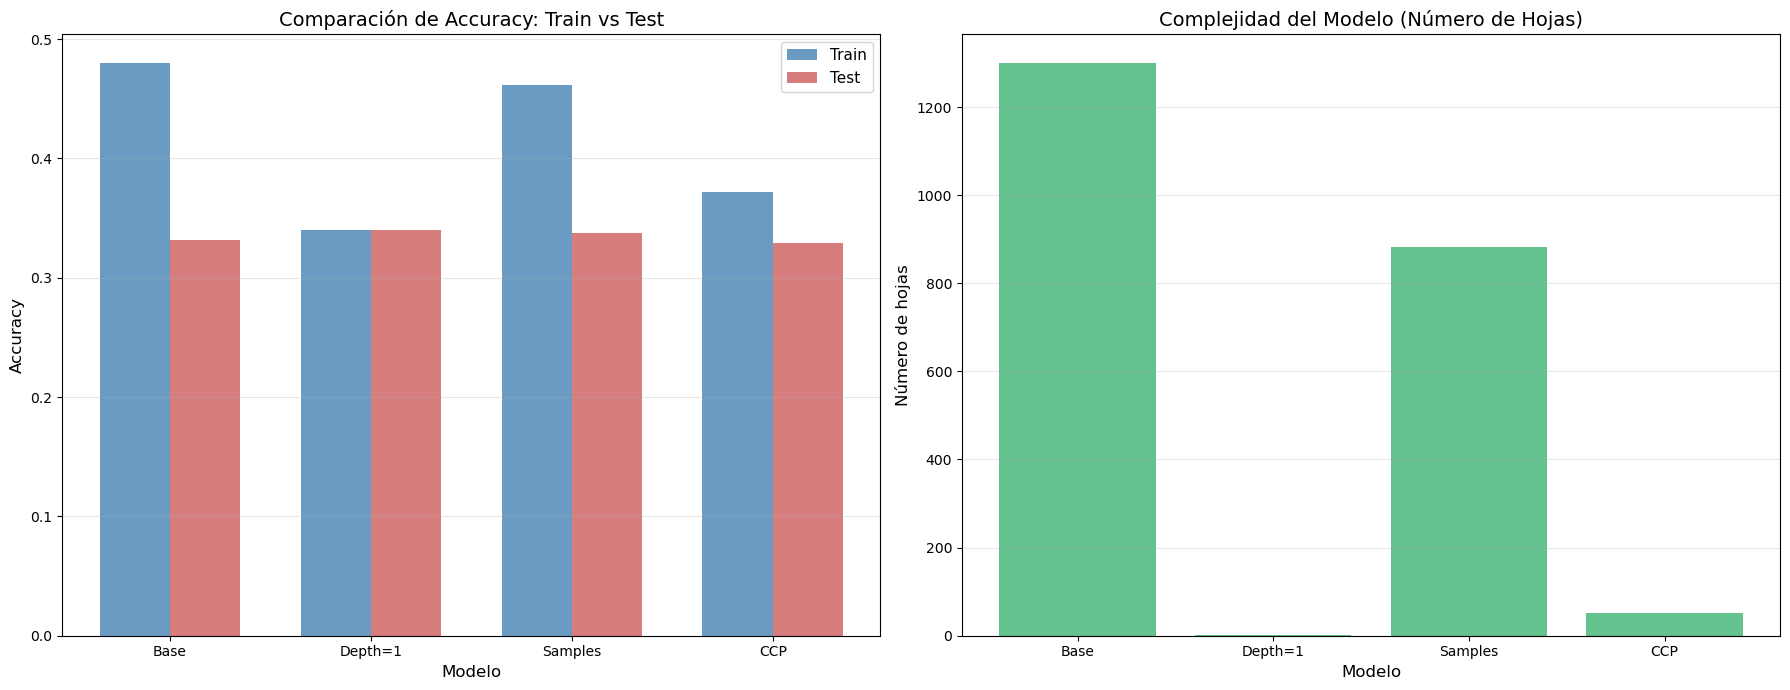

In [25]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

nombres_cortos = ['Base', f'Depth={best_max_depth}', f'Samples', f'CCP']
acc_tests = [accuracy_score(y_test, m.predict(x_test)) for m in modelos.values()]
acc_trains = [accuracy_score(y_train, m.predict(x_train)) for m in modelos.values()]
n_hojas = [m.get_n_leaves() for m in modelos.values()]

x_pos = np.arange(len(nombres_cortos))
width = 0.35

axes[0].bar(x_pos - width/2, acc_trains, width, label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x_pos + width/2, acc_tests, width, label='Test', color='indianred', alpha=0.8)
axes[0].set_xlabel('Modelo', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Comparación de Accuracy: Train vs Test', fontsize=14)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(nombres_cortos, fontsize=10)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x_pos, n_hojas, color='mediumseagreen', alpha=0.8)
axes[1].set_xlabel('Modelo', fontsize=12)
axes[1].set_ylabel('Número de hojas', fontsize=12)
axes[1].set_title('Complejidad del Modelo (Número de Hojas)', fontsize=14)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(nombres_cortos, fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

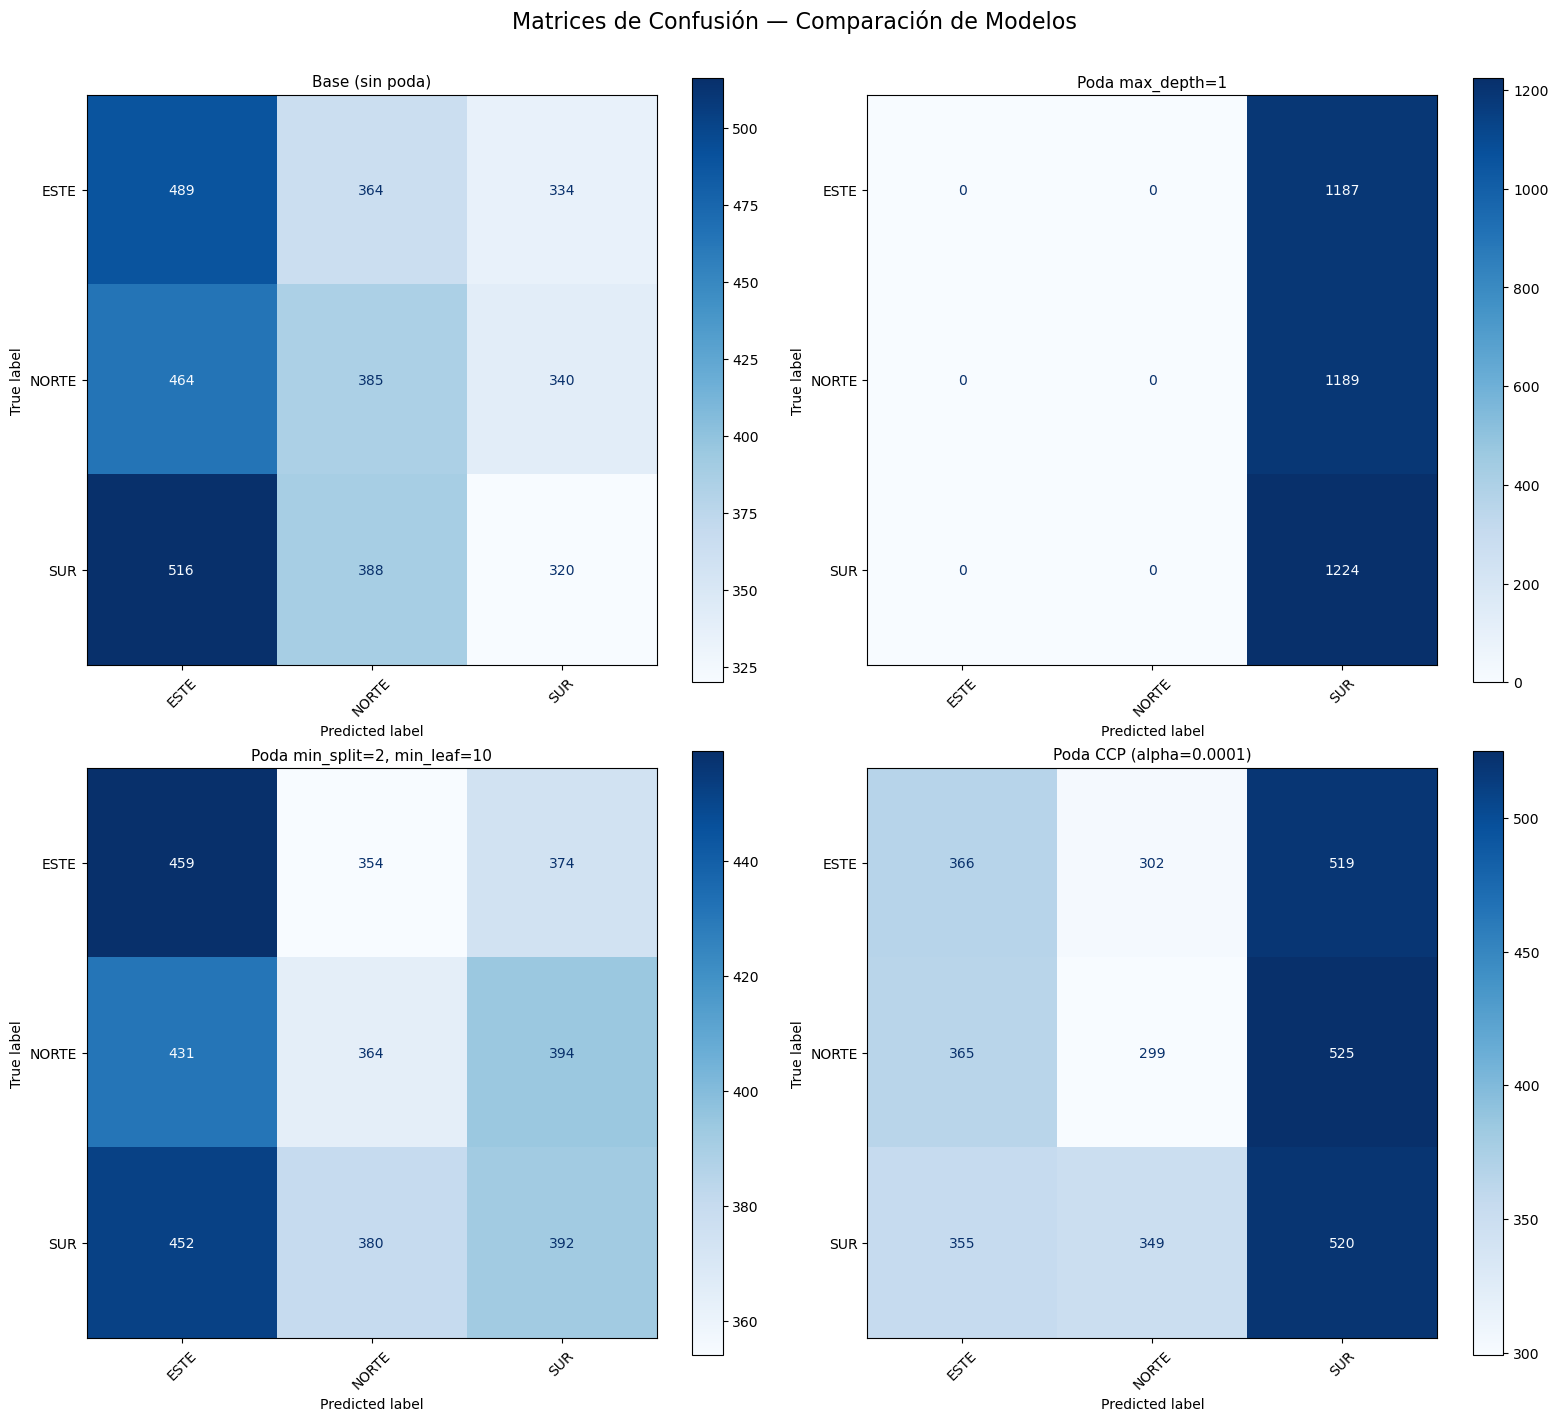

In [26]:
# Matrices de confusión de todos los modelos
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for i, (nombre, modelo) in enumerate(modelos.items()):
    y_pred = modelo.predict(x_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, ax=axes[i], cmap='Blues',
        xticks_rotation=45
    )
    axes[i].set_title(f"{nombre}", fontsize=11)

plt.suptitle("Matrices de Confusión — Comparación de Modelos", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 9. Importancia de features

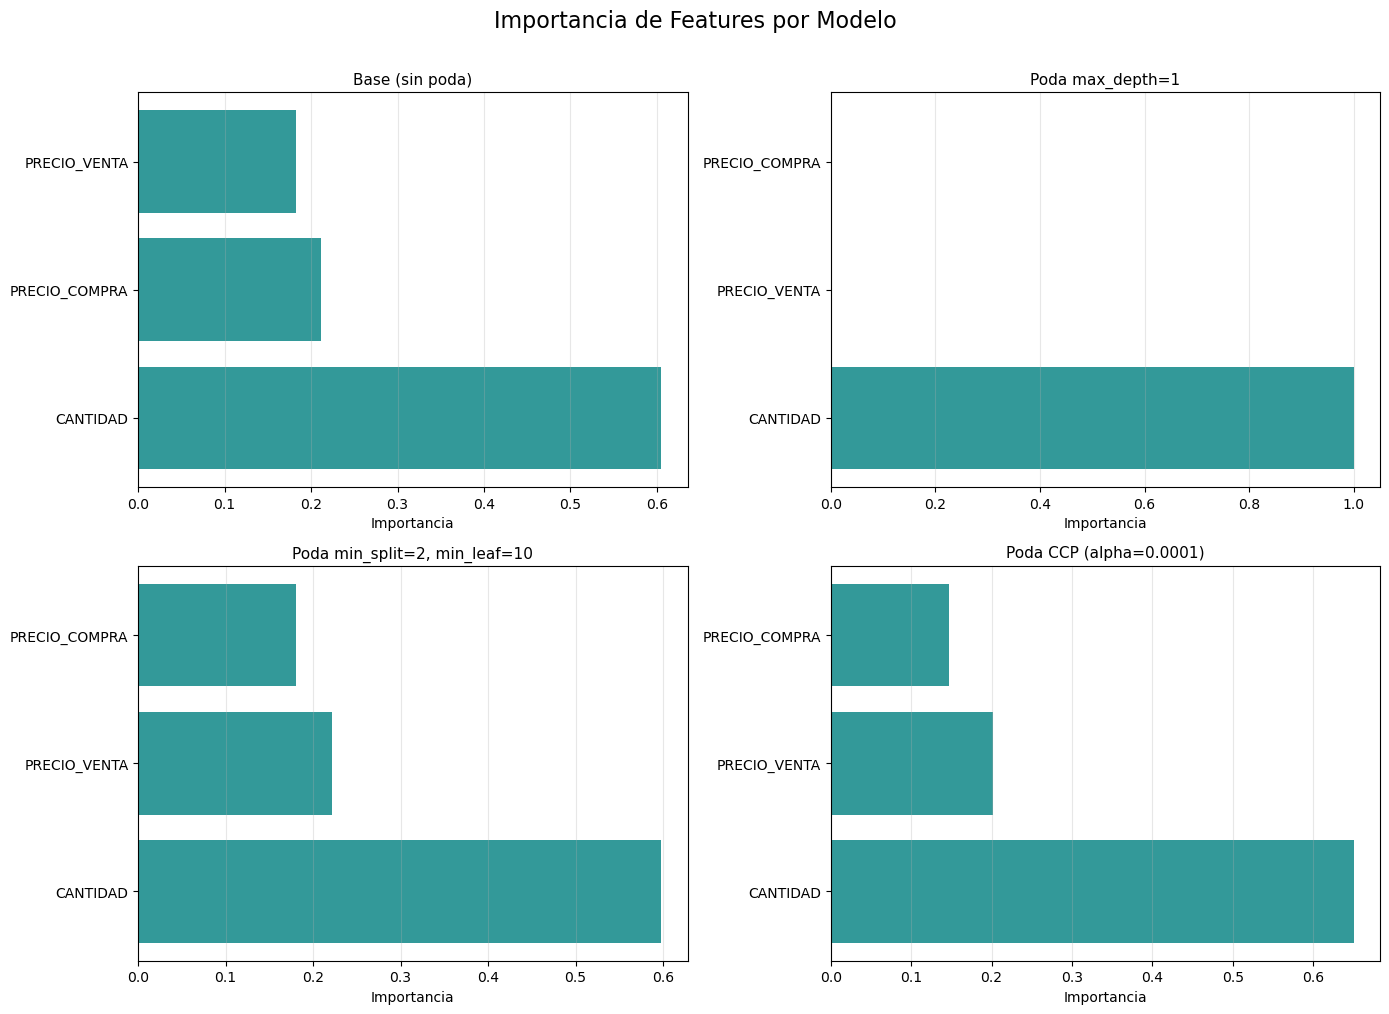

In [27]:
# Importancia de features en cada modelo
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (nombre, modelo) in enumerate(modelos.items()):
    importances = modelo.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    axes[i].barh(
        [feature_cols[j] for j in indices],
        importances[indices],
        color='teal', alpha=0.8
    )
    axes[i].set_xlabel('Importancia', fontsize=10)
    axes[i].set_title(f"{nombre}", fontsize=11)
    axes[i].grid(True, alpha=0.3, axis='x')

plt.suptitle("Importancia de Features por Modelo", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 10. Conclusiones

In [28]:
print("=" * 60)
print("RESUMEN DE CONCLUSIONES")
print("=" * 60)
print()
print("1. MODELO BASE (Sin Poda):")
print(f"   - Profundidad: {modelo_base.get_depth()}, Hojas: {modelo_base.get_n_leaves()}")
print(f"   - Accuracy test: {accuracy_score(y_test, y_pred_test_base):.4f}")
print(f"   - Overfitting: {acc_train_base - acc_test_base:.4f}")
print()
print(f"2. PODA POR PROFUNDIDAD (max_depth={best_max_depth}):")
print(f"   - Profundidad: {modelo_depth.get_depth()}, Hojas: {modelo_depth.get_n_leaves()}")
print(f"   - Accuracy test: {accuracy_score(y_test, y_pred_depth):.4f}")
print()
print(f"3. PODA POR MUESTRAS (split={best_min_split}, leaf={best_min_leaf}):")
print(f"   - Profundidad: {modelo_samples.get_depth()}, Hojas: {modelo_samples.get_n_leaves()}")
print(f"   - Accuracy test: {accuracy_score(y_test, y_pred_samples):.4f}")
print()
print(f"4. PODA POR COSTO-COMPLEJIDAD (ccp_alpha={best_alpha:.6f}):")
print(f"   - Profundidad: {modelo_ccp.get_depth()}, Hojas: {modelo_ccp.get_n_leaves()}")
print(f"   - Accuracy test: {accuracy_score(y_test, y_pred_ccp):.4f}")
print()
print("La poda reduce la complejidad del árbol y ayuda a prevenir")
print("el sobreajuste, mejorando la capacidad de generalización.")
print("\nEl mejor modelo depende del balance entre accuracy y complejidad.")

RESUMEN DE CONCLUSIONES

1. MODELO BASE (Sin Poda):
   - Profundidad: 31, Hojas: 1300
   - Accuracy test: 0.3317
   - Overfitting: 0.1483

2. PODA POR PROFUNDIDAD (max_depth=1):
   - Profundidad: 1, Hojas: 2
   - Accuracy test: 0.3400

3. PODA POR MUESTRAS (split=2, leaf=10):
   - Profundidad: 31, Hojas: 882
   - Accuracy test: 0.3375

4. PODA POR COSTO-COMPLEJIDAD (ccp_alpha=0.000117):
   - Profundidad: 16, Hojas: 51
   - Accuracy test: 0.3292

La poda reduce la complejidad del árbol y ayuda a prevenir
el sobreajuste, mejorando la capacidad de generalización.

El mejor modelo depende del balance entre accuracy y complejidad.
